### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [3]:
data = pd.read_csv('data/coupons.csv')

In [4]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0



2. Investigate the dataset for missing or problematic data.

In [124]:
# Rename Column Y to accept_coupon with values of True or False corresponding to 1 and 0
data = data.rename(columns={'Y':'accept_coupon'})
data['accept_coupon'] = data['accept_coupon'].astype(bool)
data.replace(['never','less1','1~3','4~8','gt8'], ['0', 'less than 1', '1 to 3', '4 to 8','greater than 8'], inplace=True)
data = data.rename(columns={'Bar':'barVisits'})

# Investigate Missing Dataset
missing_data = data.isnull().sum().sort_values()
print(missing_data)
accept_coupon = data.query("accept_coupon == 1")[["accept_coupon"]].value_counts()
print(accept_coupon)
total_accept_coupon = data[["accept_coupon"]].value_counts().sum()
print(total_accept_coupon)

destination                 0
direction_same              0
toCoupon_GEQ25min           0
toCoupon_GEQ15min           0
toCoupon_GEQ5min            0
income                      0
direction_opp               0
education                   0
has_children                0
occupation                  0
age                         0
gender                      0
expiration                  0
coupon                      0
time                        0
temperature                 0
weather                     0
passanger                   0
maritalStatus               0
accept_coupon               0
barVisits                 107
RestaurantLessThan20      130
CarryAway                 151
Restaurant20To50          189
CoffeeHouse               217
car                     12576
dtype: int64
accept_coupon
True             7210
Name: count, dtype: int64
12684


3. Decide what to do about your missing data -- drop, replace, other...

In [125]:
bar_data = data.dropna(subset=["barVisits"])
restaurant_data = data.dropna(subset=["RestaurantLessThan20"])
coffeehouse_data = data.dropna(subset=["CoffeeHouse"])

4. What proportion of the total observations chose to accept the coupon?



In [203]:
accept_coupon = 0
total_coupon = 0
accept_coupon = data.query("accept_coupon == 1")[["accept_coupon"]].value_counts().sum()
total_coupon = data.groupby("coupon")[["coupon","accept_coupon"]].value_counts(sort=False).sum()
accept_coupon_ratio = accept_coupon / total_coupon
print(accept_coupon_ratio.round(2))

0.57


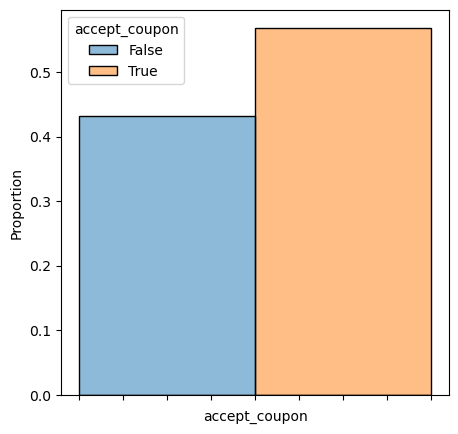

In [204]:
plt.figure(figsize = (5,5))
ax = sns.histplot(data=data,x='accept_coupon',discrete=True,stat='proportion',hue='accept_coupon')
ax.set_xticklabels([])
plt.savefig("./images/coupon_accept.png")

5. Use a bar plot to visualize the `coupon` column.

<Figure size 500x500 with 0 Axes>

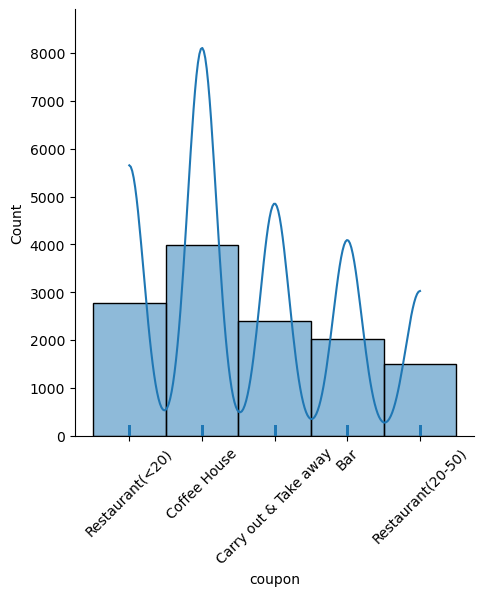

In [205]:
plt.figure(figsize=(5,5))
ax = sns.displot(data=data,x="coupon",kde= True, rug = True)
plt.xticks(rotation = 45)
plt.savefig("./images/coupon.png")

6. Use a histogram to visualize the temperature column.

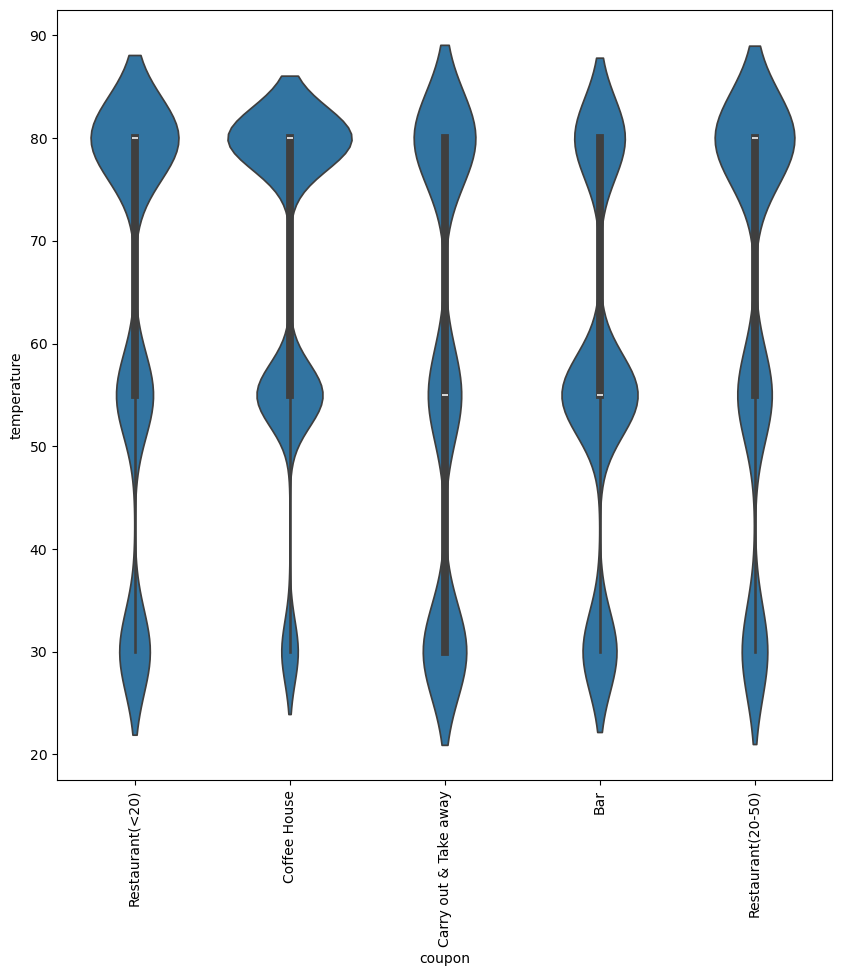

In [206]:
plt.figure(figsize=(10,10))
#sns.barplot(data=data,y="accept_coupon",x="temperature")
sns.violinplot(data=data, x="coupon", y="temperature")
plt.xticks(rotation = 90)
plt.savefig("./images/temperature.png")

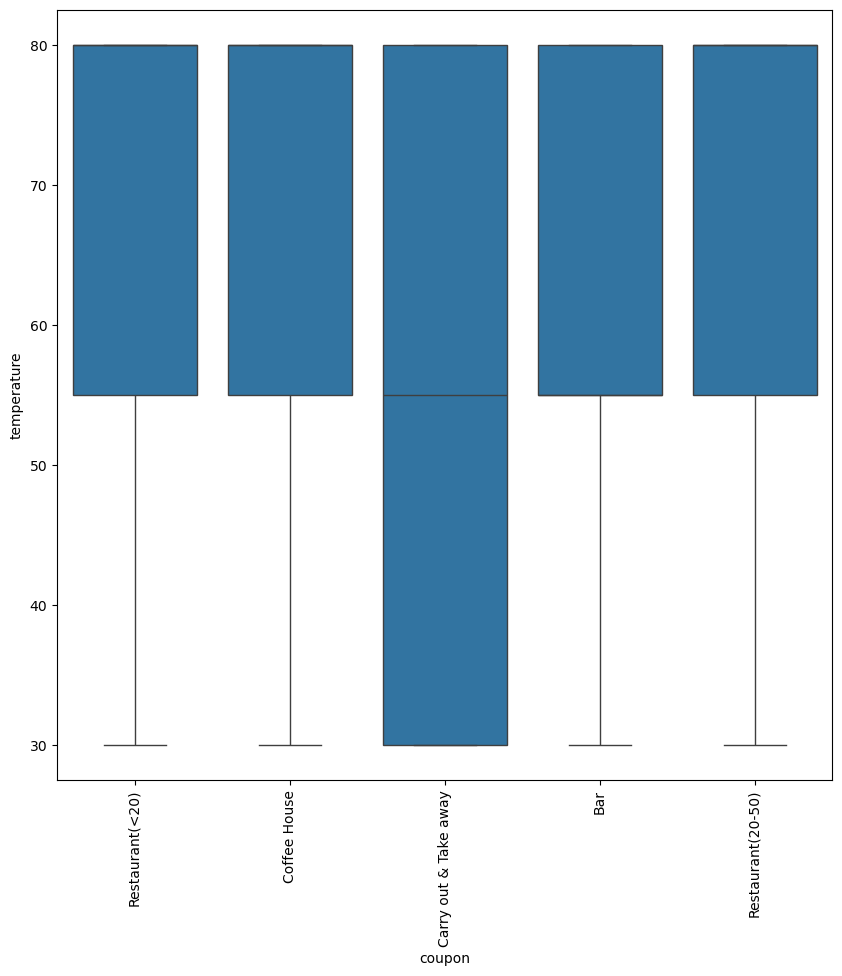

In [207]:
plt.figure(figsize=(10,10))
#sns.barplot(data=data,y="accept_coupon",x="temperature")
sns.boxplot(data=data, x="coupon", y="temperature")
plt.xticks(rotation = 90)
plt.savefig("./images/temperature1.png")

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [208]:
bar_data_df = bar_data.query('coupon == "Bar"')

2. What proportion of bar coupons were accepted?


In [209]:
bar_data_df = bar_data.query('coupon == "Bar"')
bar_accept = bar_data_df.query('accept_coupon == 1')[["accept_coupon"]].value_counts().sum()
bar_total = bar_data_df[["accept_coupon"]].value_counts().sum()
bar_count_data = {"attribute":["accept","total"],"values":[bar_accept.round(2),bar_total.round(2)]}
bar_ratio = bar_accept / bar_total
bar_ratio_data = {"attribute":["bar_accept_ratio"],"values":[bar_ratio.round(2)]}
bar_count_data = pd.DataFrame(bar_count_data)
bar_ratio_df = pd.DataFrame(bar_ratio_data)
bar_ratio_df.query("attribute == 'bar_accept_ratio'")[["attribute","values"]]

,attribute,values
0,bar_accept_ratio,0.41


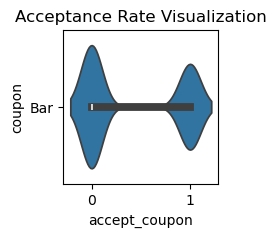

In [210]:
plt.figure(figsize=(2,2))
ax2 = sns.violinplot(data = bar_data_df, x="accept_coupon", y="coupon")
#ax2 = sns.barplot(data = bar_ratio_df, x="attribute",y="values")
ax2.set_title("Acceptance Rate Visualization")
plt.savefig("./images/barcoupon.png")

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


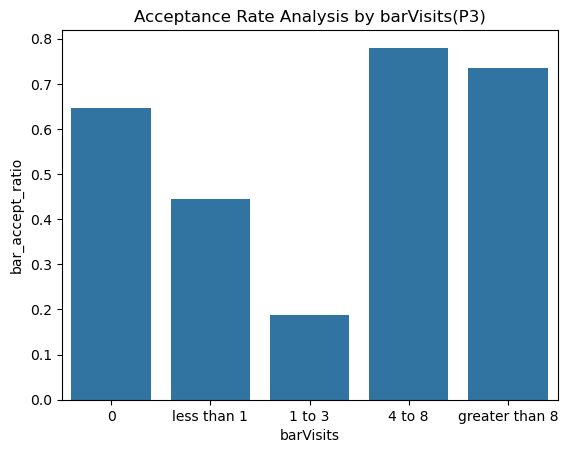

In [304]:
bar_data_df = bar_data.query('coupon == "Bar"')

barVisits_filter1 = ['0', 'less than 1', '1 to 3']

bar_acceptance_3_less = bar_data_df.query("accept_coupon == 1 and barVisits in @barVisits_filter1")[['coupon','barVisits']].value_counts().reset_index()
bar_total_3_less = bar_data_df.query("barVisits in @barVisits_filter1")[['coupon','barVisits']].value_counts().reset_index()

bar_count_3_less = pd.merge(bar_acceptance_3_less,bar_total_3_less,on = "barVisits")


ratio = {"barVisits":barVisits_filter1,"bar_ratio":[bar_count_3_less["count_x"][0]/bar_count_3_less["count_y"][0],
                                                                 bar_count_3_less["count_x"][1]/bar_count_3_less["count_y"][1],
                                                                 bar_count_3_less["count_x"][2]/bar_count_3_less["count_y"][2]]}
bar_ratio_3_less = pd.DataFrame(ratio)
bar_ratio_3_less

barVisits_filter2 = ['4 to 8','greater than 8']

bar_acceptance_other = bar_data_df.query("accept_coupon == 1 and barVisits in @barVisits_filter2")[['coupon','barVisits']].value_counts().reset_index()
bar_total_other = bar_data_df.query("barVisits in @barVisits_filter2")[['coupon','barVisits']].value_counts().reset_index()

bar_count_3_other = pd.merge(bar_acceptance_other,bar_total_other,on = "barVisits")

ratio = {"barVisits":['0', 'less than 1', '1 to 3','4 to 8','greater than 8'],"bar_accept_ratio":[bar_count_3_less["count_x"][0]/bar_count_3_less["count_y"][0],
                                                                                                                                    bar_count_3_less["count_x"][1]/bar_count_3_less["count_y"][1],
                                                                                                                                    bar_count_3_less["count_x"][2]/bar_count_3_less["count_y"][2],
                                                                                                                                    bar_count_3_other["count_x"][0]/bar_count_3_other["count_y"][0],
                                                                                                                                    bar_count_3_other["count_x"][1]/bar_count_3_other["count_y"][1]]}
bar_ratio = pd.DataFrame(ratio)
bar_ratio

ax30 = sns.barplot(data=bar_ratio,x="barVisits",y="bar_accept_ratio")
ax30.set_title("Acceptance Rate Analysis by barVisits(P3)")
plt.savefig("./images/acceptancerate30.png")



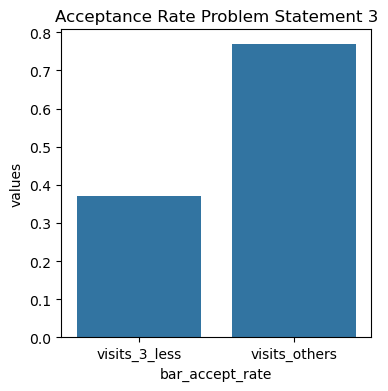

In [307]:
bar_data_df = bar_data.query('coupon == "Bar"')

barVisits_filter1 = ['0', 'less than 1', '1 to 3']
barVisits_filter2 = ['4 to 8','greater than 8']

bar_acceptance_3_less = bar_data_df.query("accept_coupon == 1 and barVisits in @barVisits_filter1")[['barVisits']].value_counts().sum()
bar_total_3_less = bar_data_df.query("barVisits in @barVisits_filter1")[['barVisits']].value_counts().sum()
bar_ratio_3_less = bar_acceptance_3_less / bar_total_3_less


bar_acceptance_others = bar_data_df.query("accept_coupon==1 and barVisits in @barVisits_filter2")[['coupon','barVisits','accept_coupon']].value_counts().sum()
bar_total_others = bar_data_df.query("barVisits in @barVisits_filter2")[['coupon','barVisits','accept_coupon']].value_counts().sum()
bar_ratio_3_others = bar_acceptance_others / bar_total_others

bar_count_data = {"count":["bar_acceptance_3_less","bar_total_3_less","bar_acceptance_others","bar_total_others"],
                  "values":[bar_acceptance_3_less,bar_total_3_less,bar_acceptance_others,bar_total_others]}

bar_ratio_data = {"bar_accept_rate":["visits_3_less","visits_others"],
                  "values":[bar_ratio_3_less,bar_ratio_3_others]}

df_count = pd.DataFrame(bar_count_data)
df_ratio = pd.DataFrame(bar_ratio_data)
plt.figure(figsize = (4,4))

df_count
ax3 = sns.barplot(data=df_ratio,x="bar_accept_rate",y="values")
ax3.set_title("Acceptance Rate Problem Statement 3")
plt.savefig("./images/acceptancerate3.png")

Acceptance Rate Analysis PS4
----------------------------


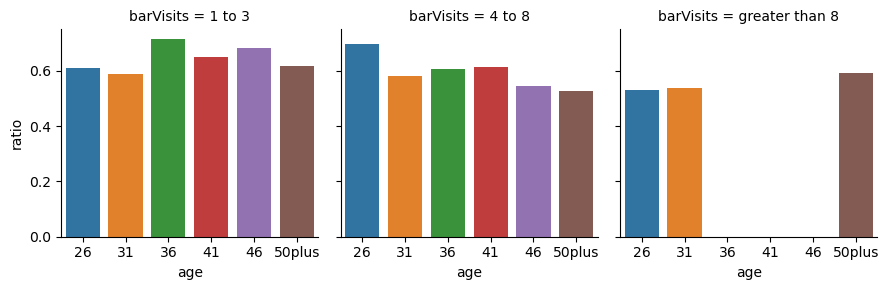

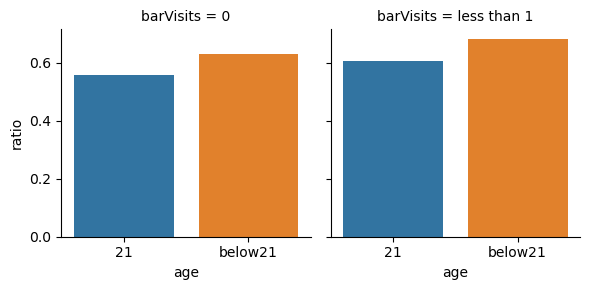

In [392]:
bar_data_df = bar_data.query('coupon == "Bar"')
barVisitsfilter41 = ['1 to 3','4 to 8','greater than 8']
barVisitsfilter42 = ['0', 'less than 1']
agefilter41 = ['26','31','36','41','46','50plus']
agefilter42 = ['21','below21']
agefilter = [agefilter41,agefilter42]

bar_acceptance_age_25_above = bar_data.query("accept_coupon==1 and barVisits in @barVisitsfilter41 and age in @agefilter41")[["barVisits","age"]].groupby(by = ["barVisits","age"]).value_counts().reset_index()
bar_total_age_25 = bar_data.query("barVisits in @barVisitsfilter41 and age in @agefilter41")[["barVisits","age"]].groupby(by = ["barVisits","age"]).value_counts().reset_index()
bar_acceptance_age_25_above["total"] = bar_total_age_25["count"]
bar_acceptance_age_25_above["ratio"] = bar_acceptance_age_25_above["count"] / bar_acceptance_age_25_above["total"]
bar_acceptance_age_25_above

bar_acceptance_others = bar_data.query("accept_coupon==1 and barVisits in @barVisitsfilter42 and age in @agefilter42")[["barVisits","age"]].groupby(by = ["barVisits"]).value_counts().reset_index()
bar_total_others = bar_data.query("barVisits in @barVisitsfilter42 and age in @agefilter42")[["barVisits","age"]].groupby(by = ["barVisits"]).value_counts().reset_index()
bar_acceptance_others["total"] = bar_total_others["count"]
bar_acceptance_others["ratio"] = bar_acceptance_others["count"]/bar_acceptance_others["total"]
bar_acceptance_others
print("Acceptance Rate Analysis PS4")
print("----------------------------")
ax40 = sns.FacetGrid(bar_acceptance_age_25_above, col="barVisits", hue = "age")
ax40.map(sns.barplot, "age", "ratio", order = ['26','31','36','41','46','50plus'])
plt.savefig("./images/acceptancerate40.png")
ax41 = sns.FacetGrid(bar_acceptance_others, col="barVisits", hue = "age")
ax41.map(sns.barplot, "age", "ratio", order = ['21','below21'])
plt.savefig("./images/acceptancerate41.png")


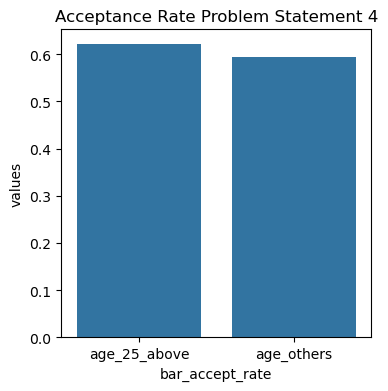

In [416]:
bar_data_df = bar_data.query('coupon == "Bar"')
barVisitsfilter41 = ['1 to 3','4 to 8','greater than 8']
barVisitsfilter42 = ['0', 'less than 1']
agefilter41 = ['26','31','36','41','46','50plus']
agefilter42 = ['21','below21']

bar_acceptance_age_25_above = bar_data.query("accept_coupon==1 and barVisits in @barVisitsfilter41 and age in @agefilter41")[["barVisits","age"]].groupby(by = ["barVisits"]).value_counts().sum()
bar_total_age_25 = bar_data.query("barVisits in @barVisitsfilter41 and age in @agefilter41")[["barVisits","accept_coupon","age"]].groupby(by = ["barVisits"]).value_counts().sum()

bar_acceptance_ratio_25_above = bar_acceptance_age_25_above.round(2) / bar_total_age_25.round(2)



bar_acceptance_others = bar_data.query("accept_coupon==1 and barVisits in @barVisitsfilter42 and age in @agefilter42")[["barVisits","age"]].groupby(by = ["barVisits"]).value_counts().sum()
bar_total_others = bar_data.query("barVisits in @barVisitsfilter42 and age in @agefilter42")[["barVisits","age"]].groupby(by = ["barVisits"]).value_counts().sum()

bar_acceptance_ratio_others = bar_acceptance_others.round(2) / bar_total_others.round(2)

bar_count_data = {"count":["bar_acceptance_age_25_above","bar_total_age_25","bar_acceptance_others","bar_total_others"],"values":[bar_acceptance_age_25_above,bar_total_age_25,bar_acceptance_others,bar_total_others]}
bar_ratio_data = {"bar_accept_rate":["age_25_above","age_others"],"values":[bar_acceptance_ratio_25_above,bar_acceptance_ratio_others]}
df_count = pd.DataFrame(bar_count_data)
df_ratio = pd.DataFrame(bar_ratio_data)

plt.figure(figsize = (4,4))

ax4 = sns.barplot(data=df_ratio,x="bar_accept_rate",y="values")
ax4.set_title("Acceptance Rate Problem Statement 4")
plt.savefig("./images/acceptancerate4.png")



5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [435]:
bar_data_df = bar_data.query('coupon == "Bar"')
passfilter = ['Alone','Friend(s)','Partner']
occfilter = ['Farming Fishing & Forestry']
bar_accept_data = None
bar_accept_data = bar_data_df.query("accept_coupon == 1 and barVisits in @barVisitsfilter41 and passanger == @passfilter and occupation != @occfilter")[["barVisits","passanger"]].groupby(by = ["barVisits","passanger"]).value_counts().reset_index()
bar_accept_data = bar_accept_data.rename(columns={'count':'accept_coupon'})
bar_accept_data

,barVisits,passanger,accept_coupon
0,1 to 3,Alone,149
1,1 to 3,Friend(s),64
2,1 to 3,Partner,32
3,4 to 8,Alone,83
4,4 to 8,Friend(s),19
5,4 to 8,Partner,11
6,greater than 8,Alone,21
7,greater than 8,Friend(s),12
8,greater than 8,Partner,2


In [439]:
bar_data_df = bar_data.query('coupon == "Bar"')
bar_total_data = bar_data_df.query("barVisits in @barVisitsfilter41 and passanger == @passfilter and occupation != @occfilter")[["barVisits","passanger"]].groupby(by = ["barVisits","passanger",]).value_counts().reset_index()
bar_accept_data["total_coupon"] = bar_total_data['count']
bar_accept_data


,barVisits,passanger,accept_coupon,total_coupon,accept_ratio
0,1 to 3,Alone,149,227,0.656388
1,1 to 3,Friend(s),64,77,0.831169
2,1 to 3,Partner,32,56,0.571429
3,4 to 8,Alone,83,101,0.821782
4,4 to 8,Friend(s),19,26,0.730769
5,4 to 8,Partner,11,16,0.687500
6,greater than 8,Alone,21,28,0.750000
7,greater than 8,Friend(s),12,17,0.705882
8,greater than 8,Partner,2,3,0.666667


In [440]:

bar_accept_data["accept_ratio"] = bar_accept_data["accept_coupon"]/bar_accept_data["total_coupon"]
bar_accept_data

,barVisits,passanger,accept_coupon,total_coupon,accept_ratio
0,1 to 3,Alone,149,227,0.656388
1,1 to 3,Friend(s),64,77,0.831169
2,1 to 3,Partner,32,56,0.571429
3,4 to 8,Alone,83,101,0.821782
4,4 to 8,Friend(s),19,26,0.730769
5,4 to 8,Partner,11,16,0.687500
6,greater than 8,Alone,21,28,0.750000
7,greater than 8,Friend(s),12,17,0.705882
8,greater than 8,Partner,2,3,0.666667


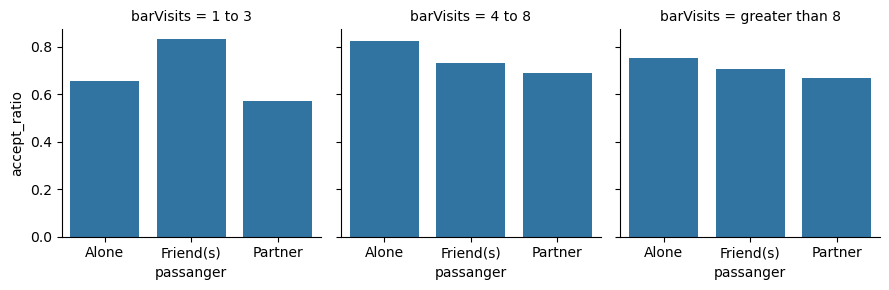

In [438]:
ax40 = sns.FacetGrid(bar_accept_data, col="barVisits")
ax40.map(sns.barplot, "passanger", "accept_ratio", order = ['Alone','Friend(s)','Partner'])
plt.savefig("./images/acceptancerate50.png")


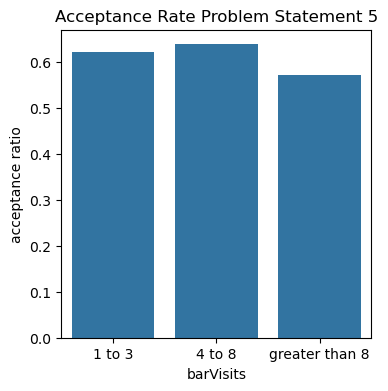

In [113]:
plt.figure(figsize = (4,4))


ax5 = sns.barplot(data=bar_occupation_ratio,x="barVisits",y="acceptance ratio")
ax5.set_title("Acceptance Rate Problem Statement 5")

plt.savefig("./images/acceptancerate5.png")


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [462]:
barVisits_filter = ['1 to 3','4 to 8','greater than 8']
passanger_filter = ['Alone','Friend(s)','Partner']
maritalStatus_filter = ['Widowed']
filter_6_1_a = "accept_coupon == 1 and barVisits in @barVisits_filter and passanger in @passanger_filter and maritalStatus != @maritalStatus_filter"
filter_6_1_t = "barVisits in @barVisits_filter and passanger in @passanger_filter and maritalStatus maritalStatus != @maritalStatus_filter"

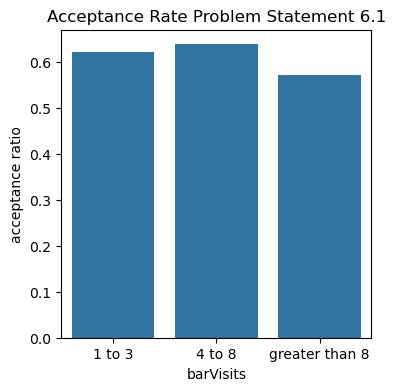

In [461]:

bar_acceptance_count_1 = bar_data.query(filter_6_1_a)[["barVisits"]].value_counts().reset_index()
bar_acceptance_count_1 = bar_acceptance_count_1.rename(columns={'count':'accept_coupon'})

bar_total_1 = bar_data.query(filter_6_1_t)[["barVisits"]].value_counts().reset_index()
bar_total_count_1 = bar_total_1.rename(columns={'count':'total_coupon'})

bar_ratio_1 = [bar_acceptance_count_1["accept_coupon"]/bar_total_count_1["total_coupon"]]
bar_ratio_1 = pd.DataFrame(bar_ratio)

bar_visit_ratio_1 = bar_total_count_1
bar_visit_ratio_1["acceptance ratio"] = bar_ratio_1.loc[0]

plt.figure(figsize = (4,4))
plt.xticks(rotation = 0)

ax61 = sns.barplot(data=bar_occupation_ratio,x="barVisits",y="acceptance ratio")
ax61.set_title("Acceptance Rate Problem Statement 6.1")

plt.savefig("./images/acceptancerate61.png")

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

**Conclusion**

From the above analysis drivers who go to the bar more than once a month and are with no passanger or friend(s) are most likely to accept the coupon.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [467]:
restaurant_data = data.dropna(subset=["RestaurantLessThan20"])
restaurant_data_df = restaurant_data.query("coupon == 'Restaurant(<20)'")
restaurant_total_data = restaurant_data_df.groupby("destination")[["passanger"]].value_counts().reset_index()

In [480]:
restaurant_accept_data = restaurant_data_df.query("accept_coupon == 1").groupby("destination")[["passanger"]].value_counts().reset_index()
restaurant_accept_data["total"] = restaurant_total_data["count"]
restaurant_accept_data["acceptance_rate"] = restaurant_accept_data["count"] / restaurant_accept_data["total"]

In [481]:
restaurant_accept_data


,destination,passanger,count,total,acceptance_rate
0,Home,Alone,220,413,0.532688
1,Home,Partner,53,80,0.662500
2,No Urgent Place,Friend(s),655,818,0.800733
3,No Urgent Place,Alone,355,441,0.804989
4,No Urgent Place,Kid(s),187,261,0.716475
5,No Urgent Place,Partner,143,175,0.817143
6,Work,Alone,333,571,0.583187


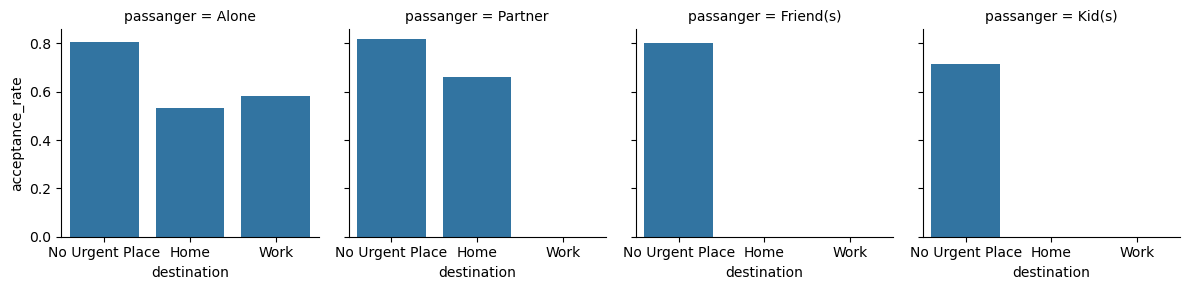

In [485]:
ax70 = sns.FacetGrid(restaurant_accept_data, col="passanger")
ax70.map(sns.barplot, "destination", "acceptance_rate", order = ['No Urgent Place','Home','Work'])
plt.savefig("./images/acceptancerate70.png")

In [510]:
restaurant_data = data.dropna(subset=["RestaurantLessThan20"])
incomefilter = ['$12500 - $24999','$25000 - $37499','$37500 - $49999','$50000 - $62499','$62500 - $74999','$75000 - $87499','$87500 - $999999','$100000 or More']
incomefilter_50k = ['$12500 - $24999','$25000 - $37499','$37500 - $49999']
incomefilter_100k = ['$50000 - $62499','$62500 - $74999','$75000 - $87499','$87500 - $999999','$100000 or More']
restaurant_data_df_50 = restaurant_data.query("coupon == 'Restaurant(<20)' and income in @incomefilter_50k")
restaurant_data_df_100 = restaurant_data.query("coupon == 'Restaurant(<20)' and income in @incomefilter_100k")
restaurant_total_50_income_data = restaurant_data_df_50.groupby("income")[["passanger"]].value_counts().reset_index()
restaurant_total_100_income_data = restaurant_data_df_100.groupby("income")[["passanger"]].value_counts().reset_index()

In [511]:
restaurant_total_50_income_data


,income,passanger,count
0,$12500 - $24999,Alone,219
1,$12500 - $24999,Friend(s),126
2,$12500 - $24999,Partner,30
3,$12500 - $24999,Kid(s),25
4,$25000 - $37499,Alone,227
5,$25000 - $37499,Friend(s),132
6,$25000 - $37499,Kid(s),44
7,$25000 - $37499,Partner,38
8,$37500 - $49999,Alone,203
9,$37500 - $49999,Friend(s),126


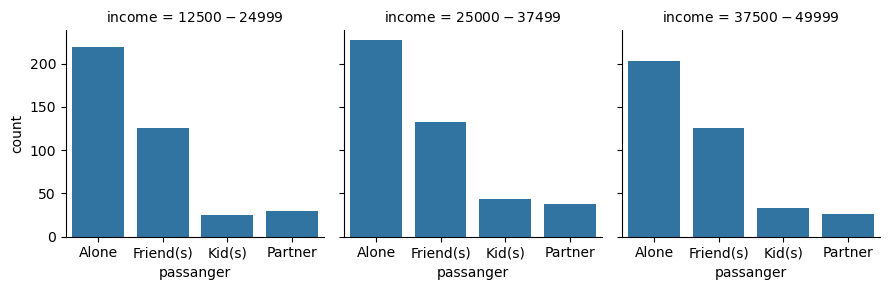

In [512]:
ax70 = sns.FacetGrid(restaurant_total_50_income_data, col="income")
ax70.map(sns.barplot, "passanger", "count", order = ['Alone','Friend(s)','Kid(s)','Partner'])
plt.savefig("./images/acceptancerate71.png")

In [513]:
restaurant_accept_data = restaurant_data_df_50.query("accept_coupon == 1 and income in @incomefilter_50k").groupby("income")[["passanger"]].value_counts().reset_index()
restaurant_accept_data
restaurant_accept_data["total"] = restaurant_total_income_data["count"]
restaurant_accept_data["acceptance_rate"] = restaurant_accept_data["count"] / restaurant_accept_data["total"]
restaurant_accept_data

,income,passanger,count,total,acceptance_rate
0,$12500 - $24999,Alone,132,188,0.702128
1,$12500 - $24999,Friend(s),99,108,0.916667
2,$12500 - $24999,Partner,25,43,0.581395
3,$12500 - $24999,Kid(s),18,40,0.450000
4,$25000 - $37499,Alone,160,219,0.730594
5,$25000 - $37499,Friend(s),110,126,0.873016
6,$25000 - $37499,Kid(s),36,30,1.200000
7,$25000 - $37499,Partner,26,25,1.040000
8,$37500 - $49999,Alone,122,227,0.537445
9,$37500 - $49999,Friend(s),101,132,0.765152


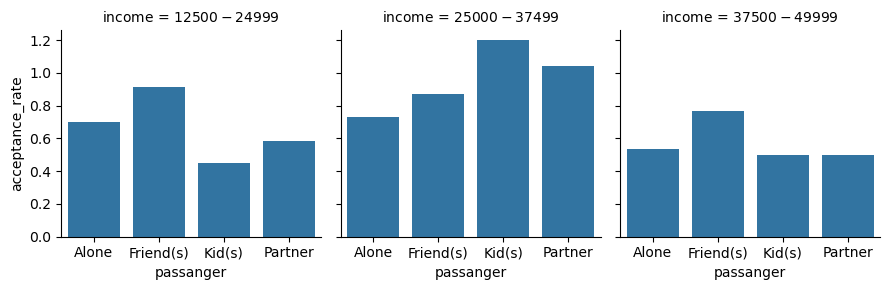

In [514]:
ax71 = sns.FacetGrid(restaurant_accept_data, col="income")
ax71.map(sns.barplot, "passanger", "acceptance_rate", order = ['Alone','Friend(s)','Kid(s)','Partner'])
plt.savefig("./images/acceptancerate72.png")

In [515]:
restaurant_total_100_income_data

,income,passanger,count
0,$100000 or More,Alone,188
1,$100000 or More,Friend(s),108
2,$100000 or More,Kid(s),43
3,$100000 or More,Partner,40
4,$50000 - $62499,Alone,165
5,$50000 - $62499,Friend(s),103
6,$50000 - $62499,Kid(s),41
7,$50000 - $62499,Partner,38
8,$62500 - $74999,Alone,93
9,$62500 - $74999,Friend(s),51


In [521]:
restaurant_data = data.dropna(subset=["RestaurantLessThan20"])
restaurant_data_df_100 = restaurant_data.query("coupon == 'Restaurant(<20)' and income in @incomefilter_100k")
restaurant_total_100_income_data = restaurant_data_df_100.groupby("income")[["accept_coupon","passanger"]].value_counts().reset_index()

restaurant_accept_data_100 = restaurant_total_100_income_data.query("accept_coupon == 1 and income in @incomefilter_100k").groupby("income")[["passanger"]].value_counts().reset_index()
restaurant_accept_data_100
restaurant_accept_data_100["total"] = restaurant_total_100_income_data["count"]
restaurant_accept_data_100["acceptance_rate"] = restaurant_accept_data_100["count"] / restaurant_accept_data_100["total"]
restaurant_accept_data_100

,income,passanger,count,total,acceptance_rate
0,$100000 or More,Alone,1,122,0.008197
1,$100000 or More,Friend(s),1,87,0.011494
2,$100000 or More,Kid(s),1,66,0.015152
3,$100000 or More,Partner,1,32,0.031250
4,$50000 - $62499,Alone,1,31,0.032258
5,$50000 - $62499,Friend(s),1,21,0.047619
6,$50000 - $62499,Kid(s),1,12,0.083333
7,$50000 - $62499,Partner,1,8,0.125000
8,$62500 - $74999,Alone,1,118,0.008475
9,$62500 - $74999,Friend(s),1,91,0.010989


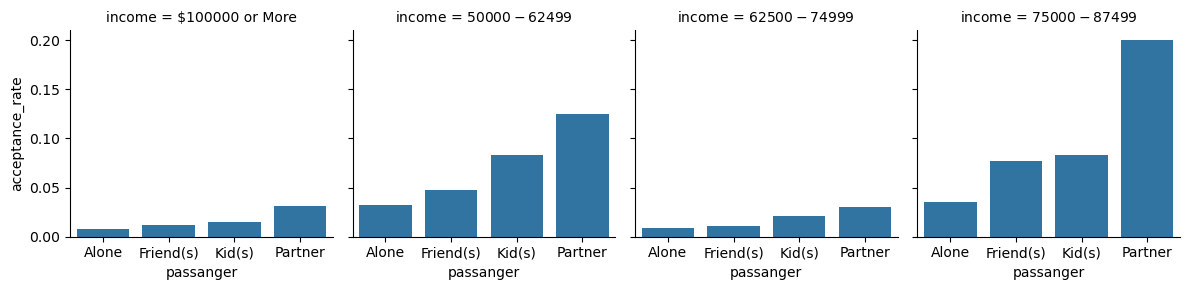

In [522]:
ax71 = sns.FacetGrid(restaurant_accept_data_100, col="income")
ax71.map(sns.barplot, "passanger", "acceptance_rate", order = ['Alone','Friend(s)','Kid(s)','Partner'])
plt.savefig("./images/acceptancerate73.png")